# Clade A results

In [81]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_A.py grid_params.py


In [82]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *

import elfi_vis
importlib.reload(elfi_vis)
from elfi_vis import *

Loading BSI_functions.py
Grid parameters:
Clade: A
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     3.895481
2005     0.000395
2006    12.635743
2007     4.214390
2008    10.536233
2009     5.791327
2010    15.351836
2011     8.640565
2012    23.632022
2013    31.851170
2014    30.044468
2015    10.125092
2016    20.251191
2017    21.300956
Name: A, dtype: float64
Model imported


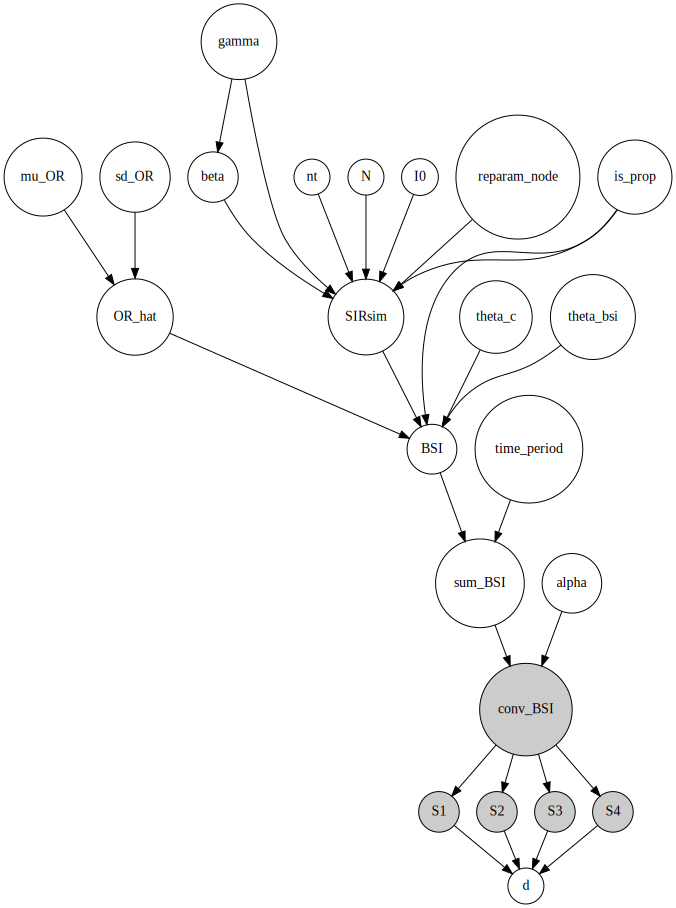

In [83]:
elfi.draw(m)

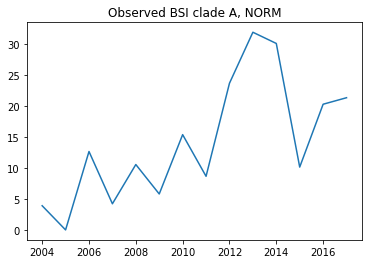

In [84]:
# Plot the observed data

plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.show()


## Visualizing the Prior

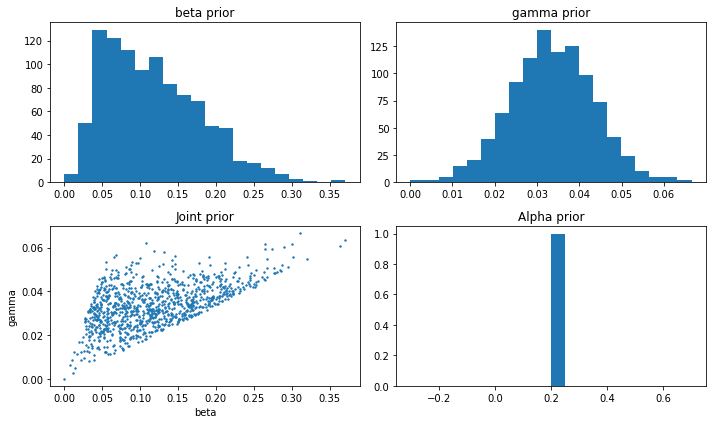

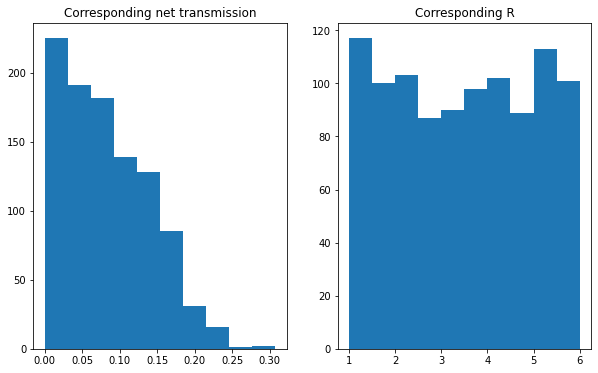

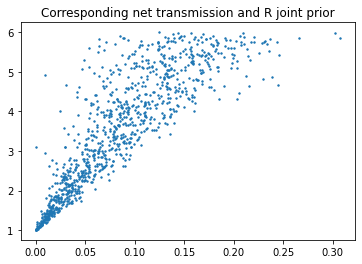

In [85]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{par2} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{par2}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.show()

if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.show()
    

    

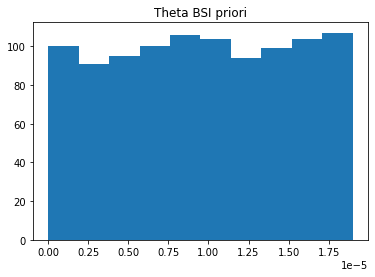

In [86]:
plt.hist(theta_bsi.generate(1000))
plt.title("Theta BSI priori")
plt.show()

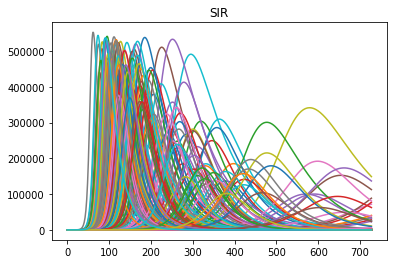

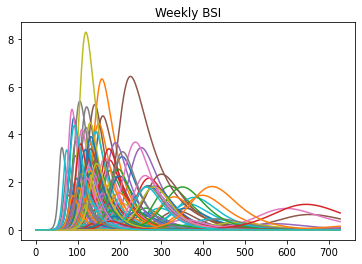

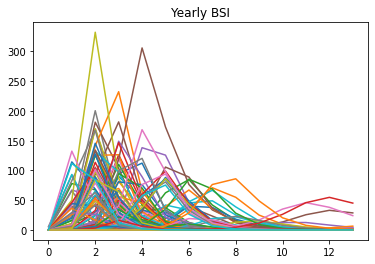

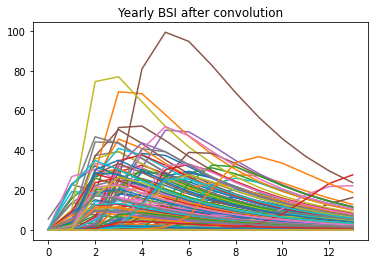

In [87]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 200, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])


plt.plot(sim_dict["SIRsim"][1][0:200].T)
plt.title("SIR")
plt.show()

plt.plot(sim_dict["BSI"][0:200].T)
plt.title("Weekly BSI")
plt.show()

plt.plot(sim_dict["sum_BSI"][0:200].T)
plt.title("Yearly BSI")
plt.show()

plt.plot(sim_dict["conv_BSI"][0:200].T)
plt.title("Yearly BSI after convolution")
plt.show()


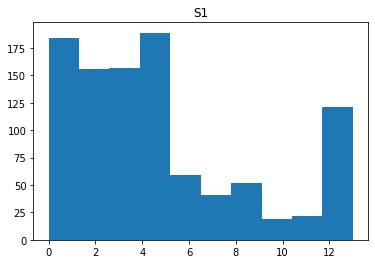

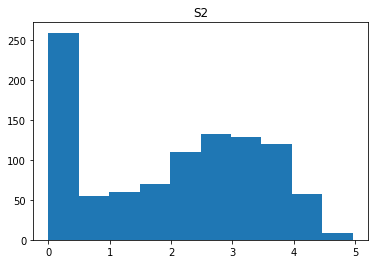

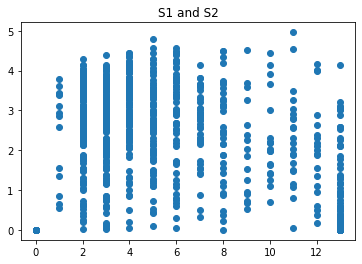

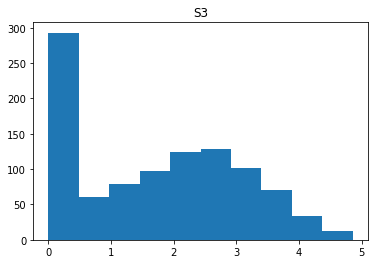

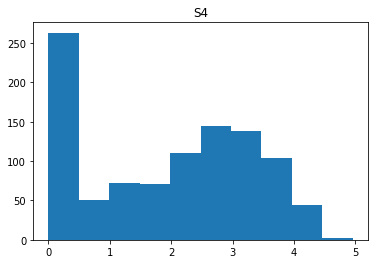

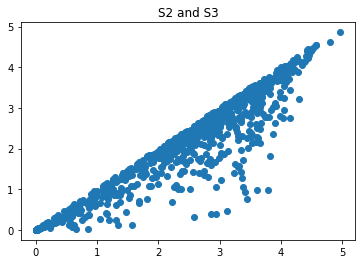

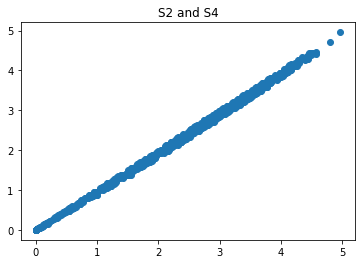

In [88]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

plt.hist(ssample["S1"])
plt.title("S1")
plt.show()

plt.hist(ssample["S2"])
plt.title("S2")
plt.show()

plt.scatter(ssample["S1"], ssample["S2"])
plt.title("S1 and S2")
plt.show()

plt.hist(ssample["S3"])
plt.title("S3")
plt.show()
plt.hist(ssample["S4"])
plt.title("S4")
plt.show()

# Summaries S3 and S4 (next and previous BSI from BSI_max) have an almost identical distribution to that of BSI_max 

plt.scatter(ssample["S2"], ssample["S3"])
plt.title("S2 and S3")
plt.show()
plt.scatter(ssample["S2"], ssample["S4"]) # Especially this. BSI_max_next
plt.title("S2 and S4")
plt.show()


## Rejection Sampling

In [89]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(10000, quantile=0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 4min 37s, sys: 4.19 s, total: 4min 41s
Wall time: 4min 36s


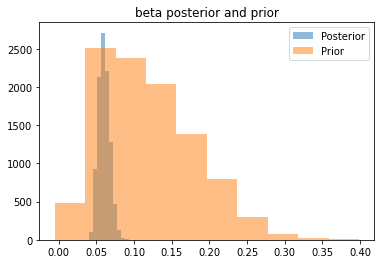

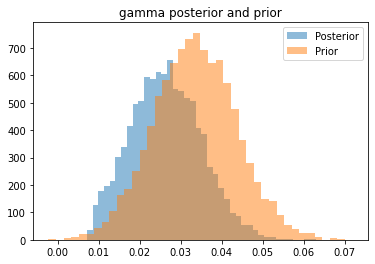

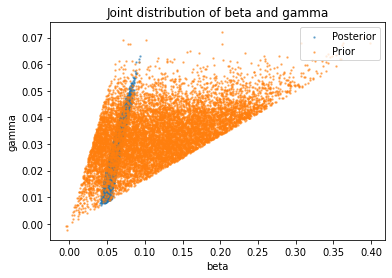

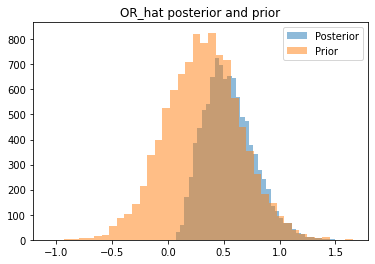

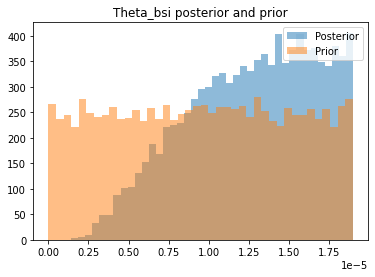

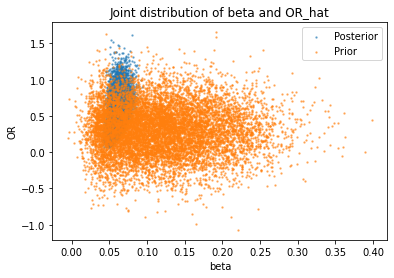

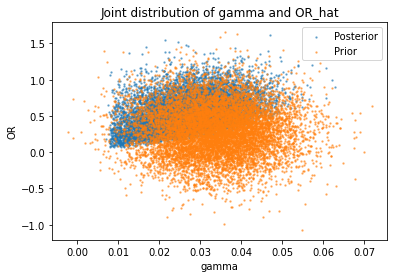

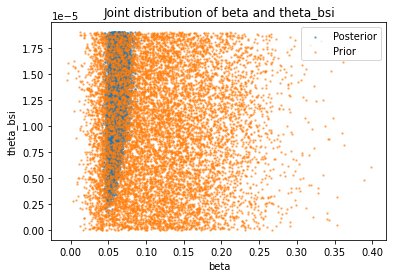

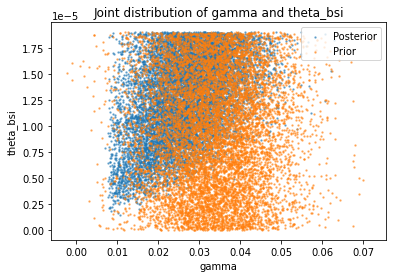

In [90]:
# Prior and posterior in the same figure

if reparam:
    par1 = "net_transmission"
    par2 = "R"
    
else:
    par1 = "beta"
    par2 = "gamma"

if not reparam:
    sample = m.generate(10000, [par1, par2, 'OR_hat', 'theta_bsi'])

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par2} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()
    
    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.show()

    try:
        # OR_hat

        plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("OR_hat posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("OR hat was not included as an estimated parameter.")

    try:
        # theta_bsi
        plt.hist(result.samples['theta_bsi'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['theta_bsi'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Theta_bsi posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("Theta_bsi was not included as an estimated parameter.")
        

    
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and OR_hat")
        plt.xlabel(f"{par1}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and OR_hat")
        plt.xlabel(f"{par2}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        pass
    
    try:
        # Joint prior: par1, theta_bsi

        plt.scatter(result.samples[par1], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and theta_bsi")
        plt.xlabel(f"{par1}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: par2, theta_bsi

        plt.scatter(result.samples[par2], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and theta_bsi")
        plt.xlabel(f"{par2}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()
    
    except:
        pass
        
        


array([[<AxesSubplot: ylabel='OR_hat'>, <AxesSubplot: >, <AxesSubplot: >,
        <AxesSubplot: >],
       [<AxesSubplot: ylabel='beta'>, <AxesSubplot: >, <AxesSubplot: >,
        <AxesSubplot: >],
       [<AxesSubplot: ylabel='gamma'>, <AxesSubplot: >, <AxesSubplot: >,
        <AxesSubplot: >],
       [<AxesSubplot: xlabel='OR_hat', ylabel='theta_bsi'>,
        <AxesSubplot: xlabel='beta'>, <AxesSubplot: xlabel='gamma'>,
        <AxesSubplot: xlabel='theta_bsi'>]], dtype=object)

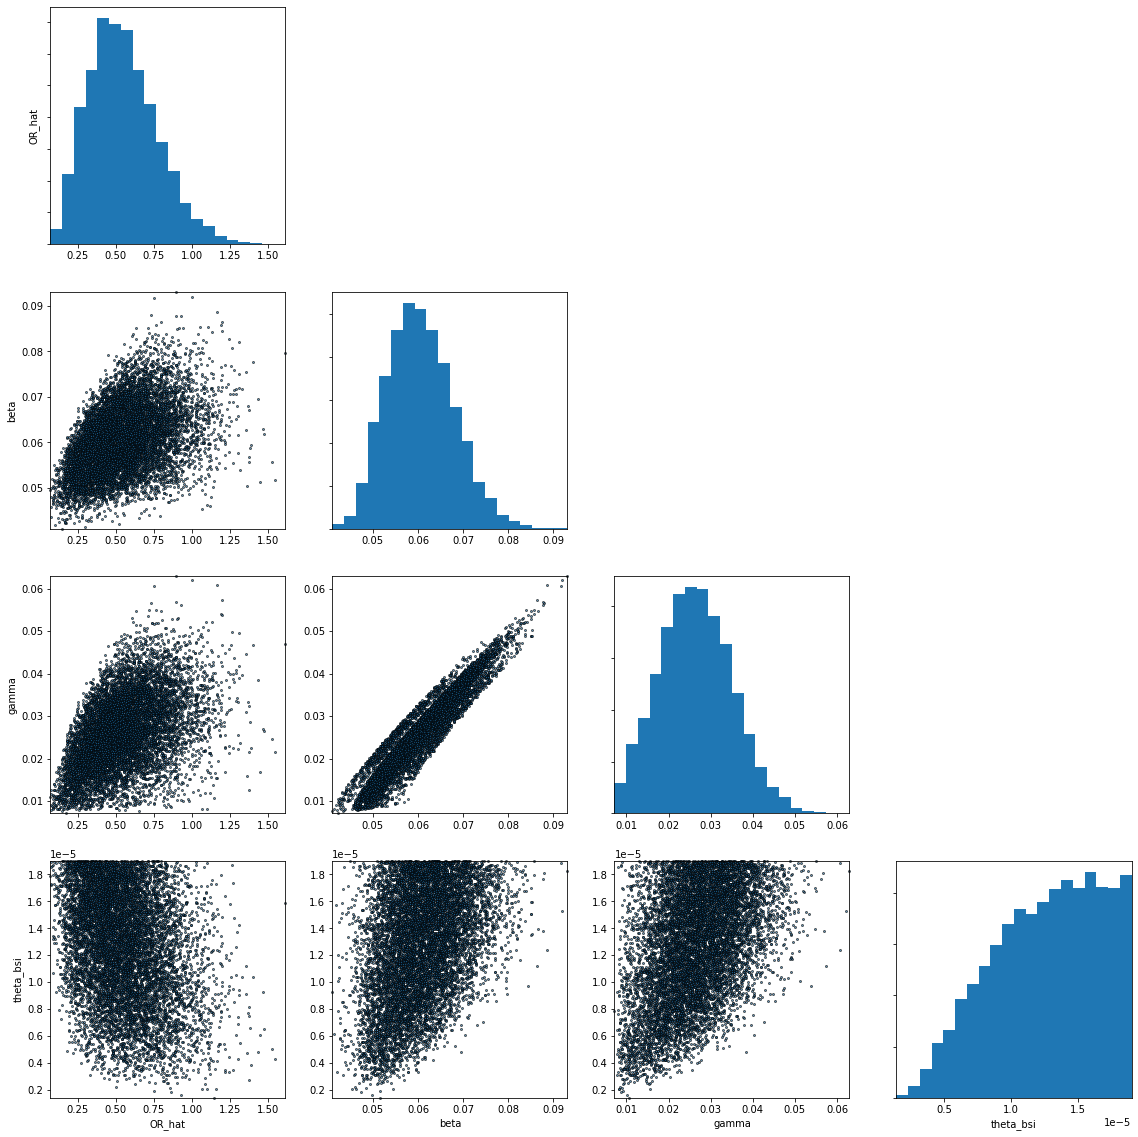

In [91]:
result.plot_pairs()

In [92]:
np.median(result.samples['theta_bsi']) # 9.6e-6 would be the estimated median value for (nt, R)
# For (beta, gamma), 1.45e-5 and not really identifiable. Why though?

1.3050118602445804e-05

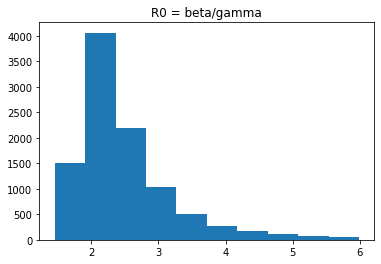

Mean of R: 2.4951539767087554
Median of R: 2.295454706460524


In [93]:
# Plotting R0

if not reparam:
    R0 = result.samples['beta']/result.samples['gamma']
else:
    R0 = result.samples['R']

plt.hist(R0)
plt.title("R0 = beta/gamma")
plt.show()

print(f"Mean of R: {R0.mean()}")
print(f"Median of R: {np.median(R0)}")

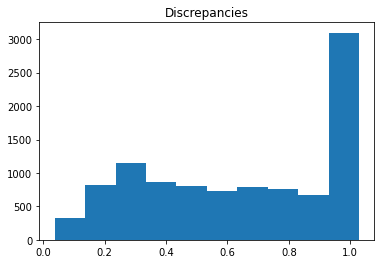

In [94]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.show()

In [95]:
# Is discrepancy ordered? -> is this plot valid?

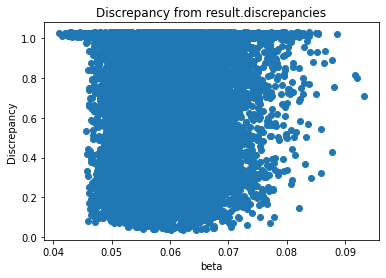

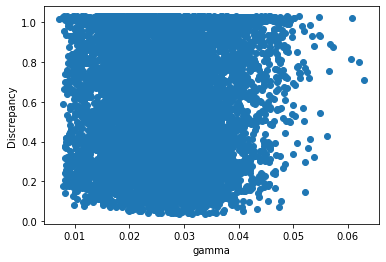

'\nplt.scatter(result.samples[\'OR_hat\'], result.discrepancies)\nplt.xlabel("OR")\nplt.ylabel("Discrepancy")\nplt.show()\n\n'

In [96]:
plt.scatter(result.samples[par1], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.show()

"""
plt.scatter(result.samples['OR_hat'], result.discrepancies)
plt.xlabel("OR")
plt.ylabel("Discrepancy")
plt.show()

"""

## Posterior predictive check

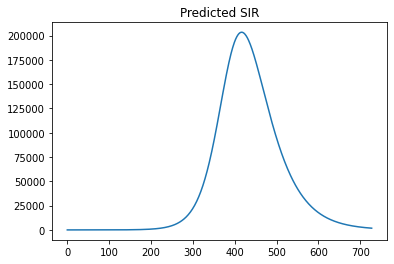

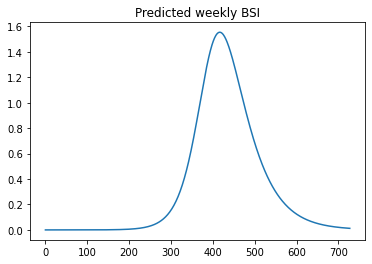

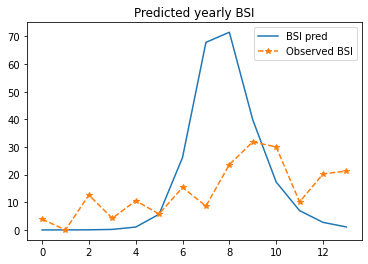

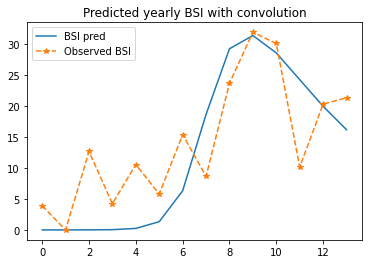

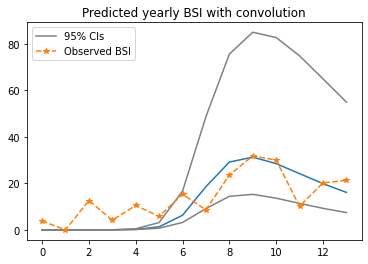

In [105]:
# Using elfi.generate

n_rep = 10 # Note: if OR hat is not fixed, we get different curves for each batch (they differ in height)

if reparam:
    par1 = "net_transmission"
    par2 = "R"
else:
    par1 = "beta"
    par2 = "gamma"

SIR_pred = SIRsim.generate(n_rep , with_values = {par1:np.mean(result.samples[par1]), par2:np.mean(result.samples[par2])}) # 10 samples, because then we can see 
    #if there's a mistake (more than 1 curve)
    
BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "theta_bsi":np.mean(result.samples["theta_bsi"]), "OR_hat":np.mean(result.samples["OR_hat"])})
BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})
BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred})

    
plt.plot(SIR_pred[1].T)
plt.title("Predicted SIR")
plt.show()

plt.plot(BSI_pred.T)
plt.title("Predicted weekly BSI")
plt.show()


plt.plot(BSI_yearly_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI")
plt.legend()
plt.show()


plt.plot(BSI_conv_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()

# 95% credible intervals: nope - ei toimi.

ci = 95
par1_ci = np.percentile(result.samples[par1], [(100-ci)/2, 100 - (100-ci)/2])
par2_ci = np.percentile(result.samples[par2], [(100-ci)/2, 100 - (100-ci)/2])


# Lower:
SIR_pred_l = SIRsim.generate(n_rep , with_values = {par1:par1_ci[0], par2:par2_ci[0]})
BSI_pred_l = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_l, "theta_bsi":np.mean(result.samples["theta_bsi"]), "OR_hat":np.mean(result.samples["OR_hat"])})
BSI_yearly_pred_l = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_l})
BSI_conv_pred_l = conv_BSI.generate(n_rep, with_values = {"sum_BSI":BSI_yearly_pred_l})

# Upper:
SIR_pred_u = SIRsim.generate(n_rep, with_values = {par1:par1_ci[1], par2:par2_ci[1]})
BSI_pred_u = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred_u, "theta_bsi":np.mean(result.samples["theta_bsi"]), "OR_hat":np.mean(result.samples["OR_hat"])})
BSI_yearly_pred_u = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_u})
BSI_conv_pred_u = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred_u})


plt.plot(BSI_conv_pred.T)
plt.plot(BSI_conv_pred_u.T, label = f"{ci}% CIs", color = "grey")
plt.plot(BSI_conv_pred_l.T, color = "grey")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()
    



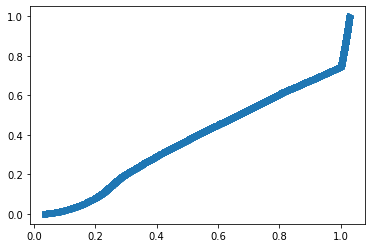

In [98]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

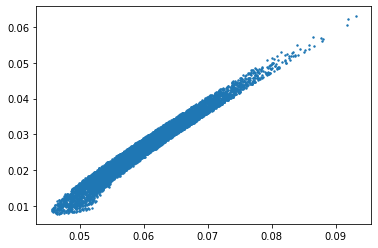

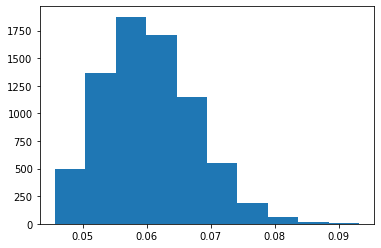

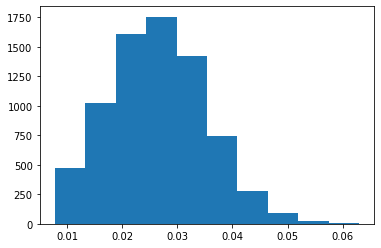

In [99]:
eps = 1
p1 = result.samples[par1][np.where(result.discrepancies < eps)]
p2 = result.samples[par2][np.where(result.discrepancies < eps)]

plt.scatter(p1, p2, s = 2) # Suspiciously regular?
plt.show()

plt.hist(p1)
plt.show()

plt.hist(p2)
plt.show()

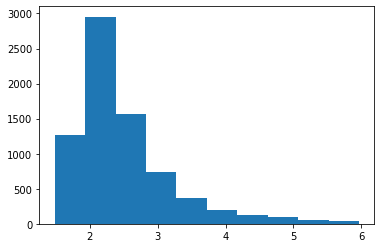

R0 mean: 2.4874945056876183
R0 median: 2.287540345291538


In [100]:
if not reparam:
    plt.hist(p1/p2)
    plt.show()
    print(f"R0 mean: {np.mean(p1/p2)}")
    print(f"R0 median: {np.median(p1/p2)}")
else:
    plt.hist(p2)
    plt.show()
    print(f"R mean: {np.mean(p2)}")
    print(f"R median: {np.median(p2)}")
    

In [101]:
get_ppc(par1 = "net_transmission", par2 = "R", fixed_means = [np.median(p1), np.median(p2)], or_hat = data_or)

NameError: name 'get_ppc' is not defined